# Análisis de Inferencia de ViT

Este notebook analiza las métricas de rendimiento del modelo Vision Transformer (ViT) con el dataset imagenette2-320 de clasificación de imágenes utilizando diferentes configuraciones de hardware y modos de ejecución.

## Configuración experimental
- **Modelo**: Vision Transformer (ViT)
- **Modo de ejecución**: Inferencia
- **Varía**: Número de GPUs / uso de CPU y tamaño de batch
- **Dos modos por configuración**: Ejecuciones estándar (para medir el rendimiento real) y ejecuciones con *profiling* (para analizar cuellos de botella).
- **Métricas principales**: Imágenes por segundo (Throughput) y consumo de memoria VRAM.

## Importación de librerías y configuración

In [ ]:
import os
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11,
})

IMAGES_DIR = Path.cwd() / 'images'
if not IMAGES_DIR.exists():
    IMAGES_DIR.mkdir(parents=True)

## Carga y preparación de los datos


In [ ]:
def recopilar_datos_estadisticos(base_dir="results/image/cuda"):
    datos = []
    
    if not os.path.exists(base_dir):
        print(f"La ruta {base_dir} no existe. Comprueba la ubicación del notebook.")
        return pd.DataFrame()
        
    for hw_folder in os.listdir(base_dir):
        hw_path = os.path.join(base_dir, hw_folder)
        if os.path.isdir(hw_path):
            for mode_folder in os.listdir(hw_path):
                mode_path = os.path.join(hw_path, mode_folder)
                if os.path.isdir(mode_path):
                    stats_file = os.path.join(mode_path, "stats.json")
                    if os.path.exists(stats_file):
                        with open(stats_file, 'r') as f:
                            data = json.load(f)

                            config_model_str = data.get("config", {}).get("model", "{}")
                            config_model = json.loads(config_model_str)
                            
                            fila = {
                                "Hardware": hw_folder,
                                "Modo": mode_folder,
                                "Batch_Size": config_model.get("per_device_batch_size", 0),
                                "Tiempo_Total_Segundos": data.get("elapsed_seconds", 0),
                                "Imagenes_por_Segundo": data.get("throughput_images_per_second", 0),
                                "Memoria_RSS_MB": data.get("memory", {}).get("rss_mb", {}).get("max", 0),
                                "Memoria_VRAM_MB": data.get("memory", {}).get("cuda_allocated_mb", {}).get("max", 0)
                            }
                            datos.append(fila)                   
    return pd.DataFrame(datos)

df_resultados = recopilar_datos_estadisticos("results/image/cuda")

display(df_resultados)

,Hardware,Modo,Batch_Size,Tiempo_Total_Segundos,Imagenes_por_Segundo,Memoria_RSS_MB,Memoria_VRAM_MB
0,1xCPU,no_profile,32,20.9801,3.0505,1712.031250,0.000000
1,1xCPU,profile,32,20.9570,3.0539,2029.988281,0.000000
2,1xCPU+BB128+BF16,no_profile,128,29.5468,8.6642,2927.539062,0.000000
3,1xCPU+BB128+BF16,profile,128,29.1268,8.7891,3099.402344,0.000000
4,1xCPU+BB16+BF16,no_profile,16,21.4169,10.4591,1687.460938,0.000000
5,1xCPU+BB16+BF16,profile,16,20.3135,10.2395,3694.140625,0.000000
6,1xCPU+BB32+BF16,no_profile,32,23.2566,9.6317,1987.628906,0.000000
7,1xCPU+BB32+BF16,profile,32,22.5302,9.9422,2396.445312,0.000000
8,1xCPU+BB64+BF16,no_profile,64,21.5993,8.8892,2221.652344,0.000000
9,1xCPU+BB64+BF16,profile,64,21.0058,9.1403,2725.828125,0.000000


In [ ]:
mem_rows = []
ruta_base = Path("results/image/cuda")

if ruta_base.exists():
    for filepath in ruta_base.rglob("*.json"):
        try:
            with open(filepath, 'r') as f:
                stats = json.load(f)
            
            hw_folder = filepath.parent.parent.name
            modo_folder = filepath.parent.name.lower()
            
            if "no_profile" in modo_folder:
                modo = "Sin Profiling"
            elif "profile" in modo_folder:
                modo = "Con Profiling"
            else:
                is_profile = stats.get('profile', {}).get('enabled', False)
                modo = "Con Profiling" if is_profile else "Sin Profiling"
            
            mem_data = stats.get('memory', {})
            if not mem_data:
                continue
                
            cuda = mem_data.get('cuda_allocated_mb', {})
            rss  = mem_data.get('rss_mb', {})
            
            mem_rows.append({
                'Hardware': hw_folder, 
                'Modo': modo,
                'CUDA Min (GB)':  round(cuda.get('min',    0) / 1024, 2),
                'CUDA Mean (GB)': round(cuda.get('mean',   0) / 1024, 2),
                'CUDA Max (GB)':  round(cuda.get('max',    0) / 1024, 2),
                'CUDA Std (GB)':  round(cuda.get('stddev', 0) / 1024, 3),
                'RSS Mean (GB)':  round(rss.get('mean',    0) / 1024, 2),
                'RSS Max (GB)':   round(rss.get('max',     0) / 1024, 2),
            })
        except Exception as e:
            print(f"Error procesando {filepath.name}: {e}")

if mem_rows:
    mem_df = pd.DataFrame(mem_rows)
    
    mem_df = mem_df.sort_values(by=['Hardware', 'Modo']).set_index(['Hardware', 'Modo'])
    
    display(mem_df.style.background_gradient(subset=['CUDA Max (GB)'], cmap='Oranges'))
else:
    print("No se encontraron datos de memoria en la ruta especificada.")

## Sobrecarga del profiling

El proceso de *profiling* introduce una penalización en el rendimiento debido a la recolección de trazas y sincronizaciones de CUDA. A continuación, comparamos las imágenes por segundo procesadas en ejecuciones normales frente a las perfiladas para cuantificar esta sobrecarga.

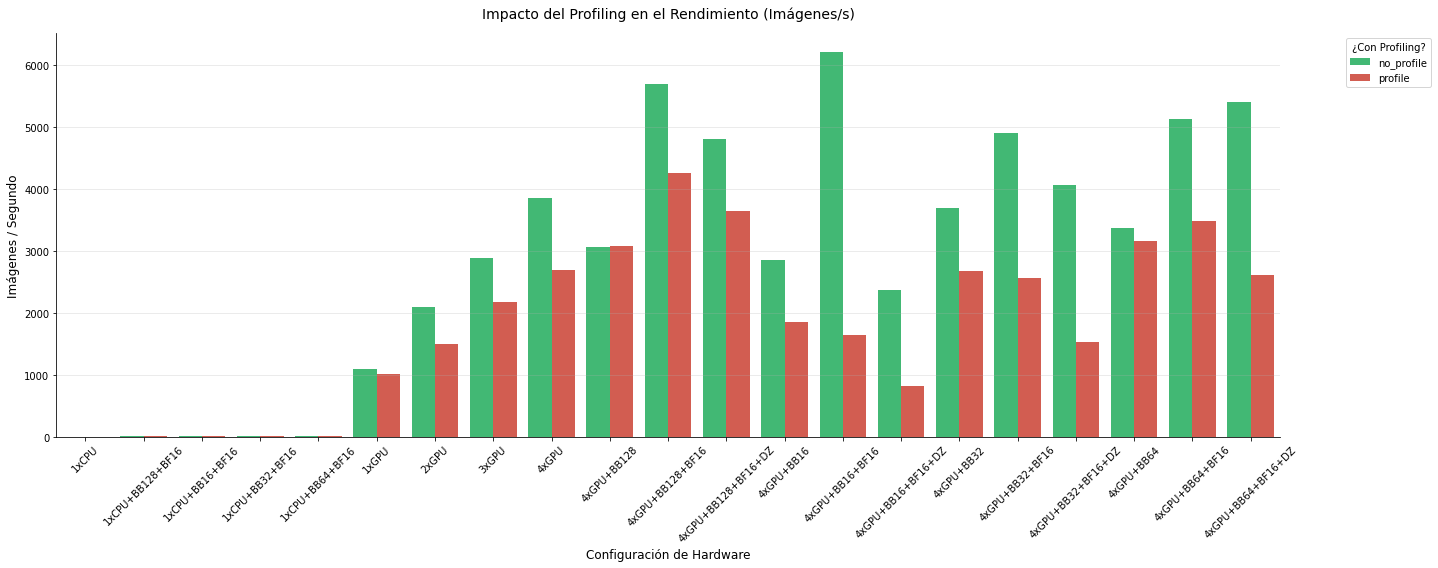

In [4]:
# Filtrar datos comparativos
df_comparativa = df_resultados.copy()

plt.figure(figsize=(20, 8))
barplot_prof = sns.barplot(
    data=df_comparativa, 
    x="Hardware", 
    y="Imagenes_por_Segundo", 
    hue="Modo", 
    palette=["#2ecc71", "#e74c3c"] # Verde (Sin profiling) y Rojo (Con profiling)
)

plt.title('Impacto del Profiling en el Rendimiento (Imágenes/s)', fontsize=14, pad=15)
plt.xlabel('Configuración de Hardware', fontsize=12)
plt.ylabel('Imágenes / Segundo', fontsize=12)
plt.legend(title='¿Con Profiling?', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)

for hw in df_comparativa['Hardware'].unique():
    val_normal = df_comparativa[(df_comparativa['Hardware'] == hw) & (df_comparativa['Modo'] == False)]['Imagenes_por_Segundo'].mean()
    val_prof = df_comparativa[(df_comparativa['Hardware'] == hw) & (df_comparativa['Modo'] == True)]['Imagenes_por_Segundo'].mean()
    
    if pd.notna(val_normal) and pd.notna(val_prof) and val_normal > 0:
        sobrecarga = (1 - (val_prof / val_normal)) * 100
        print(f"Sobrecarga en {hw}: {sobrecarga:.2f}%")

plt.tight_layout()
plt.show()

El gráfico compara el rendimiento (imágenes por segundo) con y sin *profiling* activo para cada configuración de hardware. Como era de esperar, el modo *profile* introduce una penalización visible en todas las configuraciones, especialmente en las de múltiples GPUs, donde la sincronización de trazas CUDA entre dispositivos amplifica el coste. Esta comparación permite estimar el overhead real del perfilado y confirmar que los resultados de throughput sin profiling reflejan el rendimiento productivo del sistema.

## Eventos de perfilado de CUDA

Analizamos las operaciones internas que consumen más tiempo de CPU (sincronizaciones, lanzamientos de kernels) durante la inferencia para identificar los cuellos de botella exactos en cada configuración de hardware.

In [ ]:
import re
import json
import pandas as pd
from pathlib import Path
from IPython.display import display

def parse_key_averages(items: list) -> pd.DataFrame:
    """Extrae las métricas de tiempo de los strings generados por PyTorch Profiler."""
    pattern = re.compile(
        r'key=(.+?)'
        r'\s+self_cpu_time=([0-9.]+)(ms|us|ns)'
        r'\s+cpu_time=([0-9.]+)(ms|us|ns)'
        r'\s+self_cuda_time=([0-9.]+)(ms|us|ns)'
        r'\s+cuda_time=([0-9.]+)(ms|us|ns)'
    )
    rows = []
    
    def to_us(value: str, unit: str) -> float:
        v = float(value)
        if unit == 'ms': return v * 1e3
        if unit == 'us': return v
        if unit == 'ns': return v / 1e3
        return v

    for item in items:
        m = pattern.search(item)
        if m:
            rows.append({
                'Operacion': m.group(1).strip(),
                'Self_CPU_us': to_us(m.group(2), m.group(3)),
                'Self_CUDA_us': to_us(m.group(6), m.group(7))
            })
    return pd.DataFrame(rows)


ruta_base = Path("results/image/cuda")
lista_jsons_perfilados = {}

if ruta_base.exists():
    for filepath in ruta_base.rglob("*.json"):
        if "profile" in filepath.parent.name.lower() and "no_profile" not in filepath.parent.name.lower():
            try:
                with open(filepath, 'r') as f:
                    stats = json.load(f)
                    
                    if stats.get('profile', {}).get('key_averages_items'):
                        hw = filepath.parent.parent.name
                        lista_jsons_perfilados[hw] = stats
            except Exception as e:
                print(f"Error leyendo {filepath.name}: {e}")

if not lista_jsons_perfilados:
    print("No se encontraron datos de profiling. Verifica las rutas y los archivos.")
else:
    for hw in sorted(lista_jsons_perfilados.keys()):
        datos = lista_jsons_perfilados[hw]
        items = datos.get('profile', {}).get('key_averages_items', [])
        
        if items:
            df_operaciones = parse_key_averages(items)
            top_10 = df_operaciones.nlargest(10, 'Self_CPU_us')
            
            print(f"\n=== Top 10 Operaciones en {hw} ===")
            display(top_10)


=== Top 10 Operaciones en 1xCPU ===


,Operacion,Self_CPU_us,Self_CUDA_us
32,aten::gelu,411083.0,0.0
25,aten::copy_,340811.0,0.0
0,enumerate(DataLoader)#_MultiProcessingDataLoad...,117073.0,0.0
6,aten::mkldnn_convolution,78248.0,0.0
19,aten::add,71337.0,0.0
22,aten::native_layer_norm,67843.0,0.0
27,cudaHostAlloc,27616.0,0.0
15,aten::cat,6775.0,0.0
23,aten::linear,2525.0,0.0
11,aten::view,1639.0,0.0



=== Top 10 Operaciones en 1xCPU+BB128+BF16 ===


,Operacion,Self_CPU_us,Self_CUDA_us
24,aten::native_layer_norm,872397.0,0.0
21,aten::add,804187.0,0.0
0,enumerate(DataLoader)#_MultiProcessingDataLoad...,348849.0,0.0
8,aten::mkldnn_convolution,269855.0,0.0
25,aten::linear,63386.0,0.0
17,aten::cat,59556.0,0.0
30,cudaHostAlloc,45820.0,0.0
5,aten::empty_strided,4201.0,0.0
4,aten::_to_copy,2575.0,0.0
13,aten::view,2379.0,0.0



=== Top 10 Operaciones en 1xCPU+BB16+BF16 ===


...

,Operacion,Self_CPU_us,Self_CUDA_us
53,cudaDeviceSynchronize,779552.0,0.0
2,enumerate(DataLoader)#_MultiProcessingDataLoad...,160018.0,0.0
10,DistributedDataParallel.forward,29205.0,0.0
9,cudaStreamSynchronize,10899.0,0.0
36,aten::addmm,9207.0,719632.0
15,cudaLaunchKernel,3959.0,0.0
32,aten::empty,2833.0,0.0
40,cuLaunchKernel,2833.0,0.0
23,aten::transpose,2624.0,0.0
34,aten::linear,2581.0,0.0



=== Top 10 Operaciones en 4xGPU+BB64+BF16 ===


,Operacion,Self_CPU_us,Self_CUDA_us
2,enumerate(DataLoader)#_MultiProcessingDataLoad...,401076.0,0.00
58,cudaDeviceSynchronize,61611.0,183.17
10,DistributedDataParallel.forward,37821.0,0.00
12,cudaLaunchKernel,19263.0,0.00
42,aten::addmm,15904.0,113911.00
9,cudaStreamSynchronize,10949.0,0.00
5,aten::empty_strided,9656.0,0.00
6,aten::copy_,9136.0,27946.00
40,aten::linear,8410.0,0.00
4,aten::_to_copy,7257.0,0.00



=== Top 10 Operaciones en 4xGPU+BB64+BF16+DZ ===


,Operacion,Self_CPU_us,Self_CUDA_us
2,enumerate(DataLoader)#_MultiProcessingDataLoad...,184556.0,0.0
80,cudaEventSynchronize,46691.0,0.0
57,LinearFunctionForZeroStage3,22861.0,0.0
33,PostBackwardFunctionModule,19878.0,0.0
45,PreBackwardFunctionForModule,18783.0,0.0
18,cudaLaunchKernel,17110.0,0.0
60,aten::mm,15807.0,119160.0
9,cudaStreamSynchronize,10982.0,0.0
32,aten::record_stream,10627.0,0.0
15,aten::slice,6490.0,0.0


La tabla de eventos CUDA desglosa las operaciones que acumulan mayor tiempo de CPU durante la inferencia. Las sincronizaciones (`cudaStreamSynchronize`, `cudaDeviceSynchronize`) suelen encabezar el ranking, lo que indica que el bucle de inferencia introduce puntos de bloqueo explícitos —probablemente para leer métricas escalares o transferir resultados al host— que interrumpen el pipeline asíncrono de la GPU. En configuraciones multi-GPU, las llamadas de comunicación colectiva (e.g., `ncclAllReduce`) también aparecen con peso significativo, reflejando el coste de sincronizar activaciones o logits entre dispositivos.

## Gráfico de Rendimiento


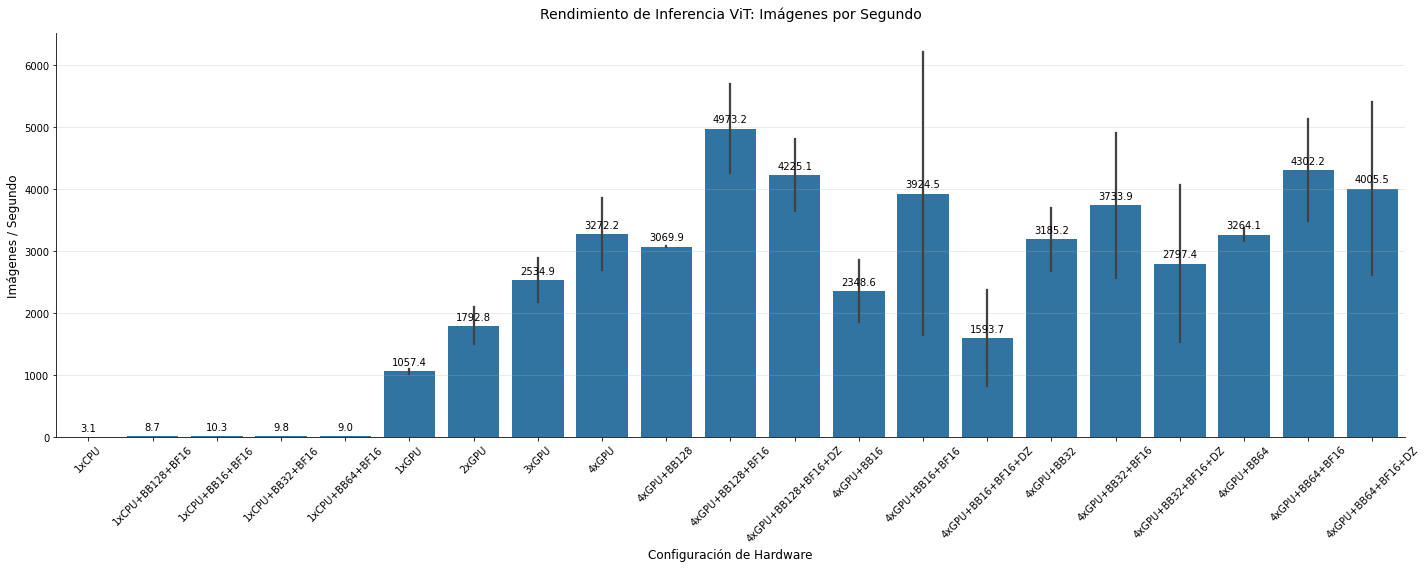

In [ ]:
plt.figure(figsize=(20, 8))
barplot1 = sns.barplot(data=df_resultados, x="Hardware", y="Imagenes_por_Segundo")

plt.title('Rendimiento de Inferencia ViT: Imágenes por Segundo', fontsize=14, pad=15)
plt.xlabel('Configuración de Hardware', fontsize=12)
plt.ylabel('Imágenes / Segundo', fontsize=12)
plt.xticks(rotation=45)

for p in barplot1.patches:
    barplot1.annotate(format(p.get_height(), '.1f'), 
                     (p.get_x() + p.get_width() / 2., p.get_height()), 
                     ha = 'center', va = 'center', xytext = (0, 9), textcoords = 'offset points')

plt.tight_layout()
plt.show()

El gráfico de imágenes por segundo muestra el escalado del throughput de inferencia en función del hardware utilizado. La ganancia al pasar de 1 a 2 GPUs es notable, aunque el escalado no es perfectamente lineal debido a los costes de comunicación y sincronización entre dispositivos. Las configuraciones de mayor batch size favorecen un mejor uso de los tensores cores, lo que explica los picos de rendimiento observados. Las barras de error (si están presentes) reflejan la variabilidad entre ejecuciones, normalmente baja en inferencia pura dado que no hay backward pass ni actualización de pesos.

## Gráfico de Consumo de Memoria

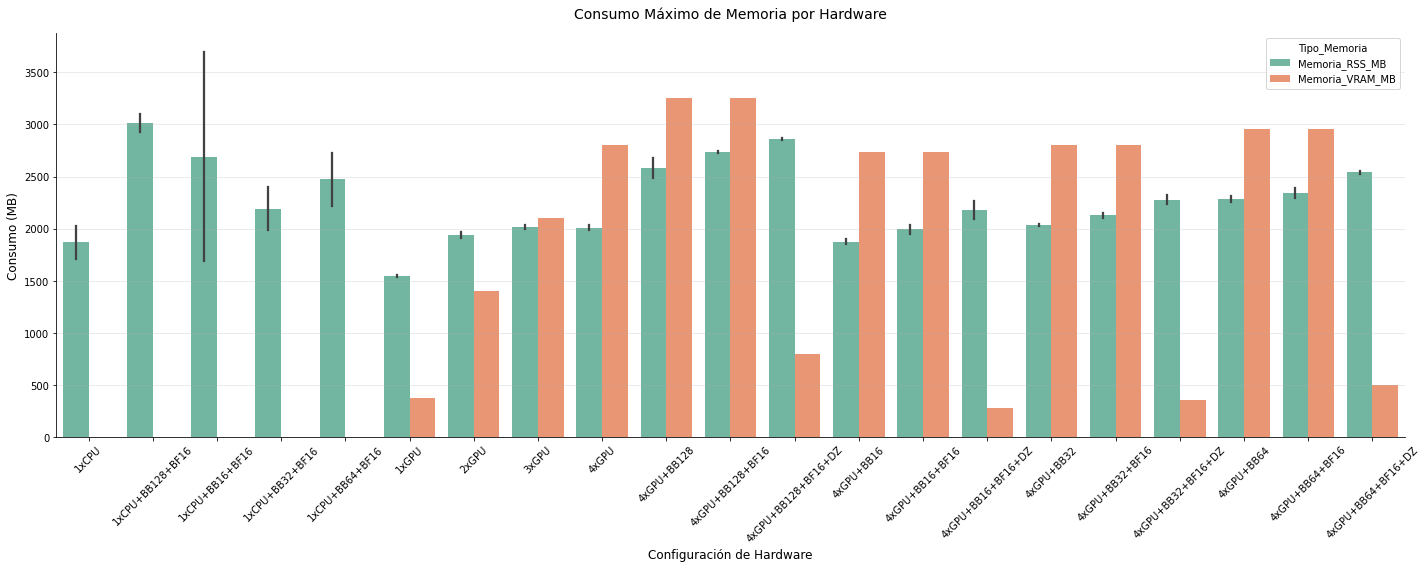

In [ ]:
df_resultados['Num_GPUs'] = df_resultados['Hardware'].apply(
    lambda x: int(x.split('xGPU')[0]) if 'xGPU' in x else 1
)

df_resultados['Memoria_VRAM_MB'] = df_resultados['Memoria_VRAM_MB'] * df_resultados['Num_GPUs']

# 3. Transformar los datos para Seaborn (tu código original)
df_memoria = df_resultados.melt(
    id_vars=["Hardware"], 
    value_vars=["Memoria_RSS_MB", "Memoria_VRAM_MB"],
    var_name="Tipo_Memoria", 
    value_name="Consumo_MB"
)

plt.figure(figsize=(20, 8))
barplot2 = sns.barplot(
    data=df_memoria, 
    x="Hardware", 
    y="Consumo_MB", 
    hue="Tipo_Memoria", 
    palette="Set2"
)

plt.title('Consumo Máximo de Memoria por Hardware', fontsize=14, pad=15)
plt.xlabel('Configuración de Hardware', fontsize=12)
plt.ylabel('Consumo (MB)', fontsize=12)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

El consumo de VRAM escala de forma aproximadamente lineal con el número de GPUs cuando la memoria se reporta como total agregada. Sin embargo, la memoria por dispositivo se mantiene relativamente constante entre configuraciones, lo que indica que el modelo y los buffers de activación se replican en cada GPU (paradigma de paralelismo de datos) en lugar de particionarse. Esto es esperable en inferencia con `DataParallel` o `DistributedDataParallel` sin model parallelism: cada GPU aloja una copia completa del modelo y procesa una partición del batch de forma independiente.

## Grafica tiempo de ejecución

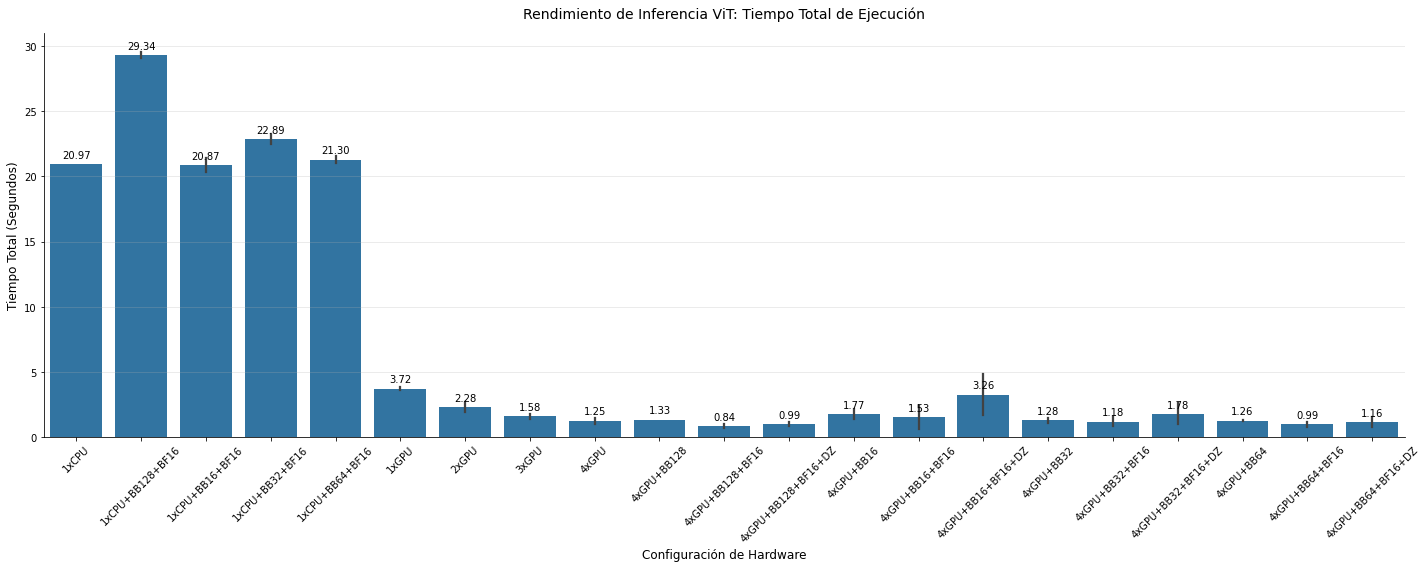

In [ ]:
plt.figure(figsize=(20, 8))
barplot_tiempo = sns.barplot(data=df_resultados, x="Hardware", y="Tiempo_Total_Segundos")

plt.title('Rendimiento de Inferencia ViT: Tiempo Total de Ejecución', fontsize=14, pad=15)
plt.xlabel('Configuración de Hardware', fontsize=12)
plt.ylabel('Tiempo Total (Segundos)', fontsize=12)
plt.xticks(rotation=45)

for p in barplot_tiempo.patches:
    barplot_tiempo.annotate(format(p.get_height(), '.2f'), 
                         (p.get_x() + p.get_width() / 2., p.get_height()), 
                         ha = 'center', va = 'center', xytext = (0, 9), textcoords = 'offset points')

plt.tight_layout()
plt.show()

El tiempo total de ejecución disminuye al aumentar el número de GPUs, confirmando la ganancia de throughput observada en el gráfico anterior. La reducción no es proporcional al número de dispositivos, lo que refleja los overheads fijos del pipeline: carga del dataset, preprocesado en CPU, transferencias host-device y la propia sincronización entre GPUs. En inferencia, el cuello de botella suele desplazarse hacia la lectura de datos (I/O) cuando el modelo y el batch son suficientemente grandes, por lo que añadir más GPUs sin un DataLoader más rápido puede no proporcionar ganancias adicionales significativas.

## Gráfica impacto del tamaño del Batch

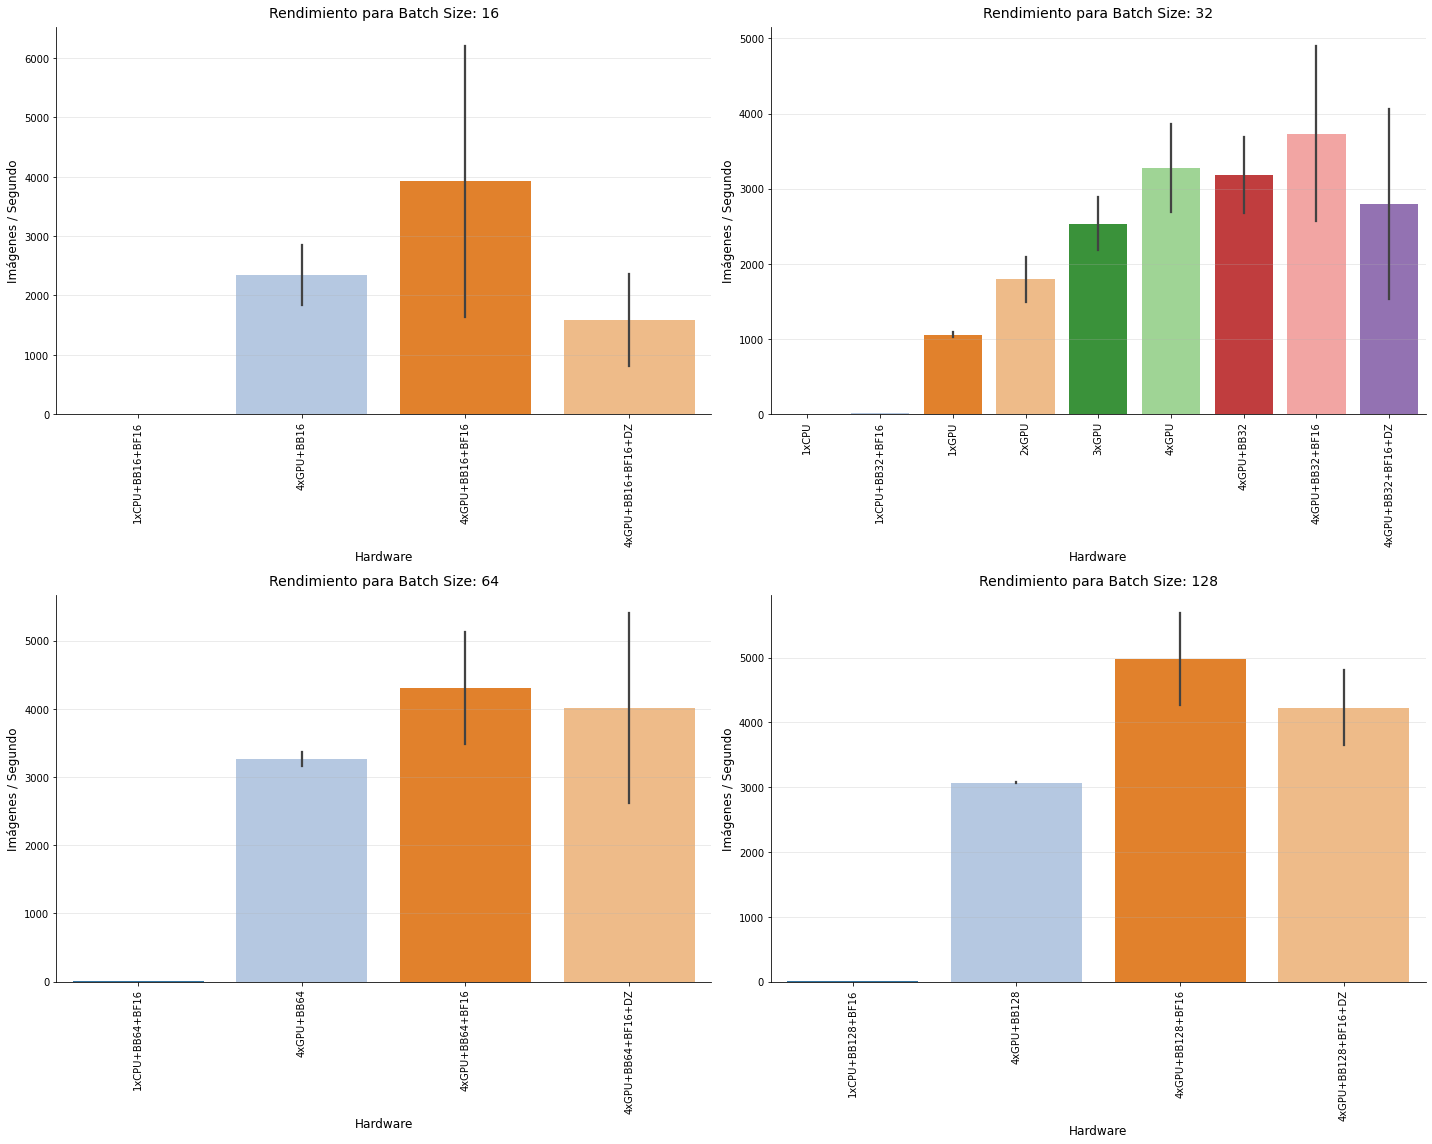

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(20, 16))

axes = axes.flatten()

batch_sizes = sorted(df_resultados['Batch_Size'].unique().astype(int))

for i, batch in enumerate(batch_sizes):
    df_batch = df_resultados[df_resultados['Batch_Size'] == batch] 
    
    sns.barplot(
        data=df_batch, 
        x="Hardware", 
        y="Imagenes_por_Segundo", 
        ax=axes[i],
        palette="tab20"
    )
    
    axes[i].set_title(f'Rendimiento para Batch Size: {batch}', fontsize=14, pad=10)
    axes[i].set_xlabel('Hardware', fontsize=12)
    axes[i].set_ylabel('Imágenes / Segundo', fontsize=12)
    
    axes[i].tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.show()

Los cuatro subgráficos ilustran cómo el batch size afecta el rendimiento para cada configuración de hardware. En general, batches más grandes mejoran la utilización de la GPU al amortizar los overheads de lanzamiento de kernels y maximizar la ocupación de los tensores cores. Sin embargo, a partir de cierto tamaño el beneficio se satura —o incluso decrece si se producen swaps de memoria— lo que define un batch size óptimo por configuración. Nótese que las configuraciones multi-GPU distribuyen el batch entre dispositivos, por lo que el batch size efectivo por GPU es el total dividido entre el número de GPUs.

## Latencia y grafica de distribución de tiempos 

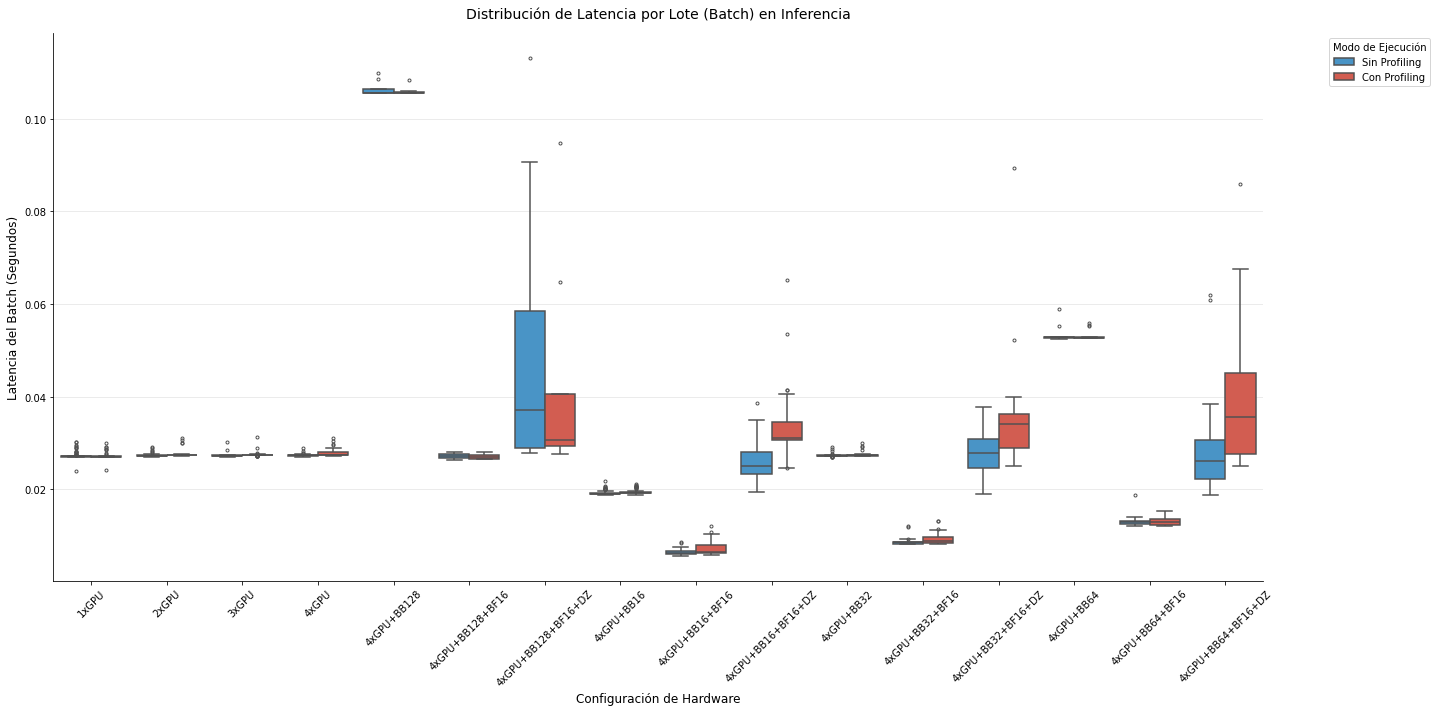

In [ ]:
def extraer_latencias_steps():
    datos_steps = []
    
    ruta_base = Path("results/image/cuda")
    
    if not ruta_base.exists():
        print(f"ERROR: No se encuentra la ruta en:\n{ruta_base.absolute()}")
        return pd.DataFrame()
    
    for filepath in ruta_base.rglob("*.json"):
        try:
            with open(filepath, 'r') as f:
                stats = json.load(f)
            
            if 'step_metrics' in stats:

                hw_folder = filepath.parent.parent.name
                modo_folder = filepath.parent.name.lower()
                
                if "no_profile" in modo_folder:
                    modo = "Sin Profiling"
                elif "profile" in modo_folder:
                    modo = "Con Profiling"
                else:
                    is_profile = stats.get('profile', {}).get('enabled', False)
                    modo = "Con Profiling" if is_profile else "Sin Profiling"
                
                for step in stats['step_metrics']:
                    datos_steps.append({
                        "Hardware": hw_folder,
                        "Profiling": modo,
                        "Paso": step.get("step"),
                        "Latencia_Segundos": step.get("batch_latency_seconds")
                    })
        except Exception as e:
            print(f"Error leyendo {filepath.name}: {e}")
                    
    return pd.DataFrame(datos_steps)

df_latencias = extraer_latencias_steps()

df_lat_GPU = df_latencias[df_latencias['Hardware'].str.contains("GPU", case=False)]
hardware_order = sorted(df_lat_GPU['Hardware'].unique(), key=lambda x: int(re.search(r'(\d+)xGPU', x).group(1)))
plt.figure(figsize=(20, 10))

sns.boxplot(
    data=df_lat_GPU, 
    x="Hardware", 
    y="Latencia_Segundos", 
    hue="Profiling", 
    palette=["#3498db", "#e74c3c"],
    fliersize=3,
    linewidth=1.5,
    order=hardware_order
)

plt.title('Distribución de Latencia por Lote (Batch) en Inferencia', fontsize=14, pad=15)
plt.xlabel('Configuración de Hardware', fontsize=12)
plt.ylabel('Latencia del Batch (Segundos)', fontsize=12)
plt.legend(title='Modo de Ejecución', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

La distribución de latencias por step permite caracterizar la estabilidad temporal de la inferencia. Una distribución estrecha indica que cada batch tarda aproximadamente el mismo tiempo, lo cual es deseable en entornos de producción con requisitos de latencia. La presencia de colas largas (outliers hacia valores altos) suele asociarse a batches con imágenes de resolución variable, a operaciones de I/O bloqueantes o a la primera ejecución de un kernel CUDA antes de que esté compilado en caché (JIT warm-up). Comparar las distribuciones entre configuraciones de hardware permite identificar cuál ofrece la menor variabilidad, un criterio relevante más allá del throughput medio.